# Statistics 2

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

**Lecture:** 10 — Oct 20

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3c_Statistics_2.ipynb)

This notebook covers:

1. Bootstrapping — building confidence intervals by resampling the data
2. Permutation tests — building a null distribution by shuffling labels
3. Noisy measurements, statistical power, and Type II error
4. Summary and exercises

Big theme:

> When formulas are hard or their assumptions shaky, we can *resample* the data itself — reshuffling and redrawing it — to see how a statistic varies and whether an effect could be chance. The same simulations let us quantify **power**: how often a real effect is actually detected.

In [1]:
# Setup

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Visualization Helpers

In [2]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def show_widget_or_fallback(widget_fn, fallback_fn):
    """Try to show an ipywidgets interaction; otherwise run a static fallback."""
    try:
        import ipywidgets as widgets
        from IPython.display import display

        display(widget_fn(widgets))
    except Exception as e:
        print("Interactive widgets are not available in this environment.")
        print("Running a static example instead.")
        fallback_fn()
        print(e)

### Data Setup
Load the penguins dataset and define group variables used throughout this notebook.

In [3]:
penguins = sns.load_dataset("penguins").dropna()

subset = penguins[penguins["species"].isin(["Adelie", "Gentoo"])].copy()
adelie = subset[subset["species"] == "Adelie"]["body_mass_g"]
gentoo = subset[subset["species"] == "Gentoo"]["body_mass_g"]
chinstrap = penguins[penguins["species"] == "Chinstrap"]["body_mass_g"].dropna()

## Bootstrapping

### Idea of the bootstrap

The **bootstrap** is a simulation-based method to approximate the sampling distribution of a statistic using the data you have.

Basic idea:

1. You have a sample of data (for example, observed body masses).
2. You repeatedly sample **with replacement** from this sample, creating many "bootstrap samples".
3. For each bootstrap sample, you compute the statistic of interest (for example, the mean).
4. The distribution of these bootstrap statistics approximates the sampling distribution.

You can then use this distribution to construct confidence intervals.


### Example: Bootstrap CI for a mean

We will construct a 95% bootstrap confidence interval for the mean body mass of Gentoo penguins.


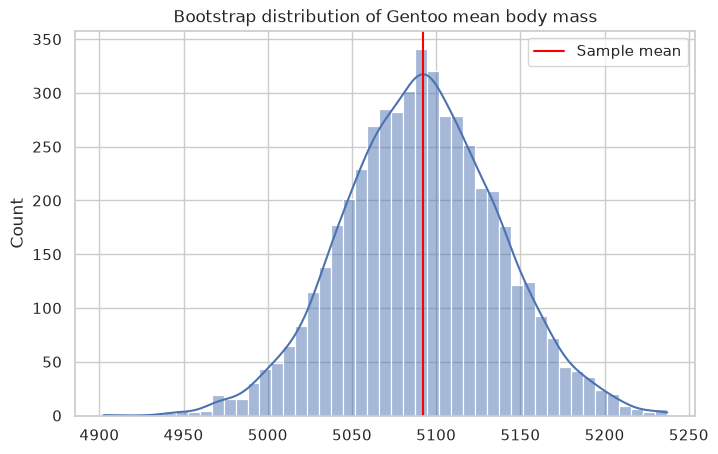

Bootstrap 95% CI for Gentoo mean body mass: (np.float64(5000.420168067227), np.float64(5182.148109243697))


In [4]:
def bootstrap_mean(data, n_boot=2000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(data)
    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_means.append(sample.mean())
    return np.array(boot_means)


gentoo_masses = gentoo.values
boot_means = bootstrap_mean(gentoo_masses, n_boot=5000)

# Plot bootstrap distribution
sns.histplot(boot_means, kde=True)
plt.axvline(gentoo_masses.mean(), color="red", label="Sample mean")
plt.title("Bootstrap distribution of Gentoo mean body mass")
plt.legend()
plt.show()

# 95% percentile interval
ci_low = np.percentile(boot_means, 2.5)
ci_high = np.percentile(boot_means, 97.5)
print("Bootstrap 95% CI for Gentoo mean body mass:", (ci_low, ci_high))

### Interactive Bootstrap: Number of Resamples

Bootstrap confidence intervals are approximate. With more bootstrap resamples, the interval estimate becomes more stable.


In [5]:
def plot_bootstrap_ci(n_boot=500, seed=0):
    boot = bootstrap_mean(gentoo_masses, n_boot=n_boot, random_state=seed)
    lo, hi = np.percentile(boot, [2.5, 97.5])

    plt.figure(figsize=(8, 4))
    sns.histplot(boot, kde=True, color="steelblue")
    plt.axvline(gentoo_masses.mean(), color="black", label="sample mean")
    plt.axvline(lo, color="crimson", linestyle="--", label="95% CI")
    plt.axvline(hi, color="crimson", linestyle="--")
    plt.title(f"Bootstrap distribution, n_boot={n_boot}\n95% CI = ({lo:.1f}, {hi:.1f})")
    plt.xlabel("bootstrap mean")
    plt.legend()
    plt.show()


def bootstrap_widget(widgets):
    return widgets.interactive(
        plot_bootstrap_ci,
        n_boot=widgets.IntSlider(
            value=500, min=50, max=5000, step=50, description="resamples"
        ),
        seed=widgets.IntSlider(value=0, min=0, max=20, step=1, description="seed"),
    )


show_widget_or_fallback(bootstrap_widget, lambda: plot_bootstrap_ci(n_boot=500, seed=0))

interactive(children=(IntSlider(value=500, description='resamples', max=5000, min=50, step=50), IntSlider(valu…

#### Exercise: Bootstrap Stability

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3c_Statistics_2.ipynb#scrollTo=ex-bootstrap-stability)

1. Try `n_boot=50` with several seeds. How much does the interval move?
2. Try `n_boot=5000`. Is it more stable?
3. What does the bootstrap distribution represent?
4. Why do we sample with replacement?


QUESTION: Compare this bootstrap confidence interval to the simple normal-approximation CI you could build using the sample mean and standard error.

Write your response here:

- Are they similar?
- When might they differ more?


## Permutation Tests

### Idea of a permutation test

When comparing two groups, a **permutation test** builds a null distribution by **shuffling group labels**.

Steps:

1. Compute the observed statistic $T_{\text{obs}}$, for example the difference in means between two groups.
2. Combine all observations into one pool.
3. Randomly shuffle the group labels, split into two permuted groups, and compute the statistic again.
4. Repeat many times to build a distribution of $T$ values under the null hypothesis "no difference between groups".
5. The p-value is the proportion of permuted statistics at least as extreme as $T_{\text{obs}}$.

This approach makes **minimal assumptions** about the underlying distributions.


### Example: Permutation test for difference in means


Observed difference (Chinstrap - Adelie): 26.92385173247385
Permutation p-value: 0.675


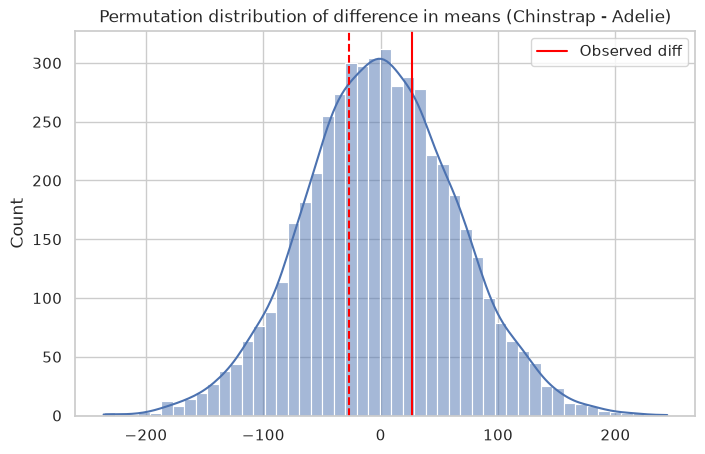

In [6]:
def permutation_test(x, y, n_perm=5000, random_state=0):
    rng = np.random.default_rng(random_state)
    observed = y.mean() - x.mean()  # mean(y) - mean(x)

    combined = np.concatenate([x, y])
    n_x = len(x)
    perm_stats = []
    for _ in range(n_perm):
        rng.shuffle(combined)
        perm_x = combined[:n_x]
        perm_y = combined[n_x:]
        perm_stats.append(perm_y.mean() - perm_x.mean())
    perm_stats = np.array(perm_stats)

    # two-sided p-value
    p_value = np.mean(np.abs(perm_stats) >= np.abs(observed))
    return observed, perm_stats, p_value


obs_diff, perm_stats, p_perm = permutation_test(
    adelie.values, chinstrap.values, n_perm=5000
)
print("Observed difference (Chinstrap - Adelie):", obs_diff)
print("Permutation p-value:", p_perm)

# Plot permutation distribution
sns.histplot(perm_stats, kde=True)
plt.axvline(obs_diff, color="red", label="Observed diff")
plt.axvline(-obs_diff, color="red", linestyle="--")
plt.title("Permutation distribution of difference in means (Chinstrap - Adelie)")
plt.legend()
plt.show()

### Visualizing the Permutation Null

The permutation distribution asks:

> What differences in means would we see if the group labels did not matter?

The observed statistic is compared to this null distribution.


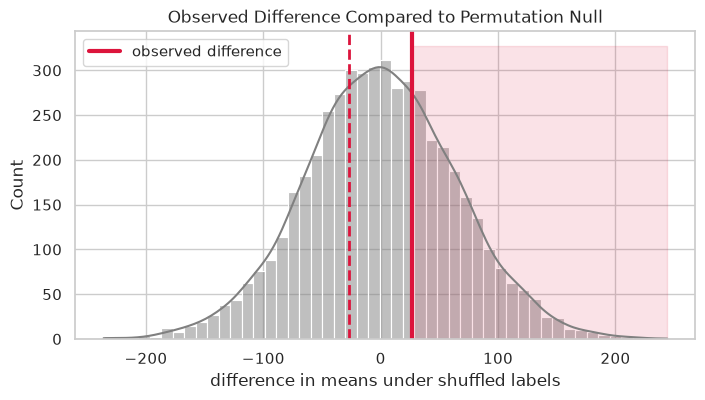

In [7]:
#| code-fold: true
plt.figure(figsize=(8, 4))
sns.histplot(perm_stats, kde=True, color="gray")
plt.axvline(obs_diff, color="crimson", linewidth=3, label="observed difference")
plt.axvline(-obs_diff, color="crimson", linewidth=2, linestyle="--")
plt.fill_betweenx(
    y=[0, plt.gca().get_ylim()[1]],
    x1=obs_diff,
    x2=max(perm_stats),
    color="crimson",
    alpha=0.12,
)
plt.title("Observed Difference Compared to Permutation Null")
plt.xlabel("difference in means under shuffled labels")
plt.legend()
plt.show()

#### Exercise: Permutation Logic

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3c_Statistics_2.ipynb#scrollTo=ex-permutation-logic)

1. What does one shuffled dataset represent?
2. Why does shuffling labels simulate the null hypothesis?
3. What does it mean if the observed statistic lies far in the tail?
4. How is this similar to and different from a t-test?


Compare this permutation-based p-value to the p-value from the t-test earlier. Are they similar? Why might they be close in this case?


## Noisy Measurements: How Measurement Error Changes Inference

In real-world science, measurements are rarely perfect.

Noise can come from:

- sensors
- experiment variability
- human factors
- environment
- recording devices

Suppose there *is* a true difference between two groups, but we measure them with noise.

Questions:

- Does noise make it harder to detect real effects?
- How do p-values and confidence intervals change?
- Why might a study fail to "find significance" even if something real is there?


In [8]:
rng = np.random.default_rng(1)

n = 50

# True underlying signal difference
true_group1 = rng.normal(0, 1, n)
true_group2 = rng.normal(0.6, 1, n)


def evaluate(x, y, description):
    t, p = stats.ttest_ind(x, y, equal_var=False)
    diff = y.mean() - x.mean()
    print(description)
    print(f" Mean difference: {diff:.3f}")
    print(f" t-statistic: {t:.3f}, p-value: {p:.4f}\n")


# Case 1: Clean measurements
evaluate(true_group1, true_group2, "No noise added")

# Case 2: Moderate sensor noise
noisy1 = true_group1 + rng.normal(0, 0.8, n)
noisy2 = true_group2 + rng.normal(0, 0.8, n)
evaluate(noisy1, noisy2, "Moderate noise added")

# Case 3: Very noisy system
very_noisy1 = true_group1 + rng.normal(0, 1.5, n)
very_noisy2 = true_group2 + rng.normal(0, 1.5, n)
evaluate(very_noisy1, very_noisy2, "High noise added")

No noise added
 Mean difference: 0.525
 t-statistic: -3.054, p-value: 0.0029

Moderate noise added
 Mean difference: 0.562
 t-statistic: -2.422, p-value: 0.0173

High noise added
 Mean difference: 0.635
 t-statistic: -1.958, p-value: 0.0530



### Interactive Demo: Noise, Sample Size, and Power

In **Statistics 1** we named two mistakes a test can make: a **Type I
error** (a false positive, controlled by $\alpha$) and a **Type II error** (missing
a real effect, with probability $\beta$). Here we finally *measure* the second one.

The **power** of a test is $1 - \beta$: the probability of detecting an effect that
is genuinely present. When the effect below is real, every experiment that comes
back with $p \ge 0.05$ is a Type II error — a real difference we failed to catch.

This simulation repeats the same experiment many times and estimates the power as
the fraction of runs with a p-value below the $\alpha = 0.05$ threshold. Watch how
power collapses as noise grows or the sample shrinks — and how it recovers as $n$
increases.


In [9]:
def estimate_power(effect=0.6, noise=1.0, n=50, n_experiments=500, seed=4):
    rng = np.random.default_rng(seed)
    p_values = []

    for _ in range(n_experiments):
        g1 = rng.normal(0, noise, n)
        g2 = rng.normal(effect, noise, n)
        _, p_value = stats.ttest_ind(g1, g2, equal_var=False)
        p_values.append(p_value)

    p_values = np.array(p_values)
    power = np.mean(p_values < 0.05)

    plt.figure(figsize=(7, 4))
    sns.histplot(p_values, bins=30, color="steelblue")
    plt.axvline(0.05, color="crimson", linestyle="--", label="0.05 threshold")
    plt.title(f"Estimated power = {power:.2f}\neffect={effect}, noise={noise}, n={n}")
    plt.xlabel("p-value across repeated experiments")
    plt.legend()
    plt.show()

    print(f"Estimated power: {power:.3f}")


def power_widget(widgets):
    return widgets.interactive(
        estimate_power,
        effect=widgets.FloatSlider(
            value=0.6, min=0.0, max=2.0, step=0.1, description="effect"
        ),
        noise=widgets.FloatSlider(
            value=1.0, min=0.2, max=3.0, step=0.1, description="noise"
        ),
        n=widgets.IntSlider(value=50, min=10, max=300, step=10, description="n"),
        n_experiments=widgets.IntSlider(
            value=500, min=100, max=2000, step=100, description="experiments"
        ),
        seed=widgets.IntSlider(value=4, min=0, max=20, step=1, description="seed"),
    )


show_widget_or_fallback(
    power_widget,
    lambda: estimate_power(effect=0.6, noise=1.0, n=50, n_experiments=500, seed=4),
)

interactive(children=(FloatSlider(value=0.6, description='effect', max=2.0), FloatSlider(value=1.0, descriptio…

#### Exercise: Designing a Better Experiment

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3c_Statistics_2.ipynb#scrollTo=ex-designing-better-experiment)

Use the power demo.

1. What happens to power when noise increases?
2. What happens to power when sample size increases?
3. Can a real effect be missed when noise is high or sample size is small?
4. What design choices could improve power before collecting data?


### What happened?

- Did the mean difference stay similar?
- What happened to the p-value as noise increased?
- What does this say about:
  - power of a test
  - experiment design
  - data quality
  - sample size needs?

Key takeaway:
> Noise does not "erase" signal, but it makes it harder to see. Uncertainty increases, p-values increase, and confidence intervals widen — so the chance of a **Type II error** (missing a real effect) goes up and power goes down. A non-significant result in a noisy, small study is not evidence that nothing is there.


## Summary

In this notebook, we:

- Implemented **bootstrap** confidence intervals for a mean by resampling the data with replacement.
- Built a **permutation test**, generating an empirical null distribution by shuffling group labels.
- Simulated how **noise and sample size** control **statistical power** ($1 - \beta$), and saw how easily a real effect produces a **Type II error** when power is low.

This completes **Module 3**, which moved from probability to inference:

- **Probability** — distributions and their generating processes, ending in the Central Limit Theorem.
- **Statistics 1** — covariance/correlation, confidence intervals, and hypothesis tests (t-test, ANOVA, paired t-test), with Type I and Type II errors.
- **Statistics 2** — simulation-based inference (bootstrap, permutation) and statistical power.

Together these tools form the statistical backbone for evaluating models and reasoning about uncertainty in later parts of the course.


## Additional Exercises:

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3c_Statistics_2.ipynb#scrollTo=ex-exercise)


## Diabetes Dataset Inference Exercises

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3c_Statistics_2.ipynb#scrollTo=ex-diabetes-dataset-inference)

You will now apply hypothesis testing and resampling methods to the Diabetes dataset.

---

### Exercise 1 — Two-Group Comparison (Welch t-test)

We split patients into:

- Low BMI (below median)
- High BMI (above median)

Answer:

1. Which group has higher average diabetes progression?
2. What is the sign of the t-statistic and what does it tell you?
3. Is the p-value small or large?
4. Based on the boxplot:
   - Do the distributions overlap?
   - Could some low BMI patients still have worse outcomes?

Reflection:
> What question does the t-test answer in this context?

---

### Exercise 2 — ANOVA Across BMI Quartiles

We compared 4 BMI groups using ANOVA.

Answer:

1. What is the null hypothesis?
2. What does a significant ANOVA result actually claim?
3. Does ANOVA tell us which groups differ?

Reflection:
> Why might ANOVA say "significant" even if distributions overlap?

---

### Exercise 3 — Permutation Testing

Compare:

- Permutation p-value
- Welch t-test p-value

Answer:

1. Are they similar?
2. Which method assumes less?
3. Why might permutation testing be attractive in biomedical settings?

---

### Final Reflection

Write a short paragraph:

- What does "evidence of a difference" mean in this dataset?
- Does statistical significance mean clinical importance?
- How do noise and variability shape what we conclude?

import numpy as np

In [10]:
from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)
df = data.frame
df["target"] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


N low BMI:  218
N high BMI: 224
Mean outcome (low BMI):  112.76
Mean outcome (high BMI): 190.45
Welch Two-Sample t-test
t-statistic: 12.303
p-value:     0.000000


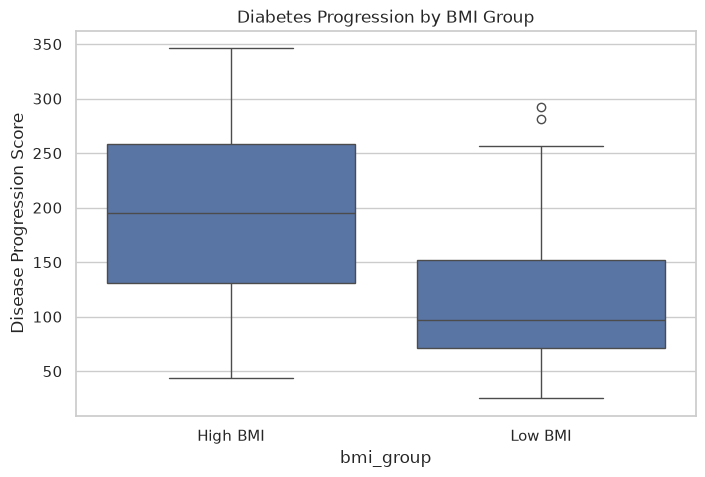

F-statistic: 61.056
p-value:     0.000000


In [11]:
### Split into low and high BMI
median_bmi = df["bmi"].median()

low_bmi = df[df["bmi"] < median_bmi]["target"]
high_bmi = df[df["bmi"] >= median_bmi]["target"]

print(f"N low BMI:  {len(low_bmi)}")
print(f"N high BMI: {len(high_bmi)}")

print(f"Mean outcome (low BMI):  {low_bmi.mean():.2f}")
print(f"Mean outcome (high BMI): {high_bmi.mean():.2f}")


### Welch two-sample t-test

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(high_bmi, low_bmi, equal_var=False)

print("Welch Two-Sample t-test")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_val:.6f}")

### Visualize the difference

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(
    data=df.assign(bmi_group=np.where(df["bmi"] >= median_bmi, "High BMI", "Low BMI")),
    x="bmi_group",
    y="target",
)

plt.title("Diabetes Progression by BMI Group")
plt.ylabel("Disease Progression Score")
plt.show()

### One-way ANOVA

df["bmi_quartile"] = pd.qcut(
    df["bmi"], 4, labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
)

groups = [g["target"].values for _, g in df.groupby("bmi_quartile")]

from scipy.stats import f_oneway

F, p = f_oneway(*groups)

print(f"F-statistic: {F:.3f}")
print(f"p-value:     {p:.6f}")

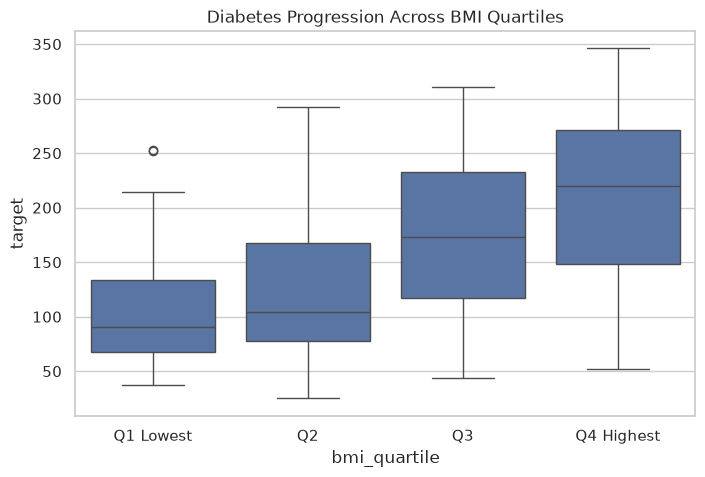

In [12]:
#| code-fold: true
sns.boxplot(data=df, x="bmi_quartile", y="target")
plt.title("Diabetes Progression Across BMI Quartiles")
plt.show()

In [13]:
def permutation_test(x, y, n_perm=5000, random_state=0):
    rng = np.random.default_rng(random_state)
    observed = y.mean() - x.mean()

    combined = np.concatenate([x, y])
    n_x = len(x)

    perm_stats = []
    for _ in range(n_perm):
        rng.shuffle(combined)
        perm_x = combined[:n_x]
        perm_y = combined[n_x:]
        perm_stats.append(perm_y.mean() - perm_x.mean())

    perm_stats = np.array(perm_stats)
    p_value = np.mean(np.abs(perm_stats) >= np.abs(observed))
    return observed, perm_stats, p_value


obs_diff, perm_stats, p_perm = permutation_test(low_bmi.values, high_bmi.values)

print("Observed difference (High BMI - Low BMI):", obs_diff)
print("Permutation p-value:", p_perm)

Observed difference (High BMI - Low BMI): 77.6894249672346
Permutation p-value: 0.0


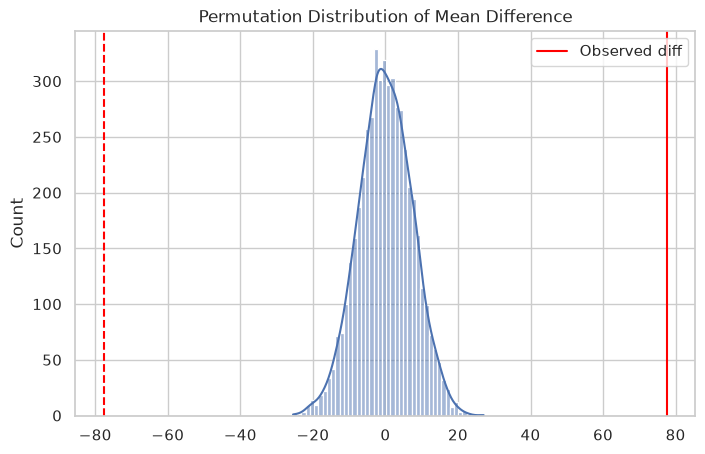

In [14]:
#| code-fold: true
sns.histplot(perm_stats, kde=True)
plt.axvline(obs_diff, color="red", label="Observed diff")
plt.axvline(-obs_diff, color="red", linestyle="--")
plt.title("Permutation Distribution of Mean Difference")
plt.legend()
plt.show()